In [ ]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm  # Imported for logarithmic color scale

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

In [2]:
# Load averaged results
date_one_to_one_gaussian = "03081457"
with open(f"../Results_averaged/lorenz63_qrc_gaussian_results_{date_one_to_one_gaussian}_averaged.pkl", "rb") as f:
    data_one_to_one_gaussian = pickle.load(f)

date_fill_gaussian = "03111048"
with open(f"../Results_averaged/lorenz63_qrc_gaussian_results_{date_fill_gaussian}_averaged.pkl", "rb") as f:
    data_fill_gaussian = pickle.load(f)

date_dense_gaussian = "03081501"
with open(f"../Results_averaged/lorenz63_qrc_gaussian_results_{date_dense_gaussian}_averaged.pkl", "rb") as f:
    data_dense_gaussian = pickle.load(f)

date_one_to_one_spin = "03160921"
with open(f"../Results_averaged/lorenz63_qrc_tilted_tfim_results_{date_one_to_one_spin}_averaged.pkl", "rb") as f:
    data_one_to_one_spin = pickle.load(f)

date_fill_spin = "03161007"
with open(f"../Results_averaged/lorenz63_qrc_tilted_tfim_results_{date_fill_spin}_averaged.pkl", "rb") as f:
    data_fill_spin = pickle.load(f)

date_dense_spin = "03161009"
with open(f"../Results_averaged/lorenz63_qrc_tilted_tfim_results_{date_dense_spin}_averaged.pkl", "rb") as f:
    data_dense_spin = pickle.load(f)

In [3]:
df2_one_to_one_gaussian = pd.DataFrame(data_one_to_one_gaussian)
df2_fill_gaussian = pd.DataFrame(data_fill_gaussian)
df2_dense_gaussian = pd.DataFrame(data_dense_gaussian)

df2_one_to_one_spin = pd.DataFrame(data_one_to_one_spin)
df2_fill_spin = pd.DataFrame(data_fill_spin)
df2_dense_spin = pd.DataFrame(data_dense_spin)


In [4]:
models_data = [
    ("DV-QRC", [
        ("Local", df2_one_to_one_spin),
        ("Clustered", df2_fill_spin),
        ("Global", df2_dense_spin)
    ]),
    ("CV-QRC", [
        ("Local", df2_one_to_one_gaussian),
        ("Clustered", df2_fill_gaussian),
        ("Global", df2_dense_gaussian)
    ])
]


--- Processing Metric: NRMSE ---
Min NRMSE for DV-QRC (Local): 0.0467
Min NRMSE for DV-QRC (Clustered): 0.0394
Min NRMSE for DV-QRC (Global): 0.0408
Min NRMSE for CV-QRC (Local): 0.0354
Min NRMSE for CV-QRC (Clustered): 0.0251
Min NRMSE for CV-QRC (Global): 0.0212


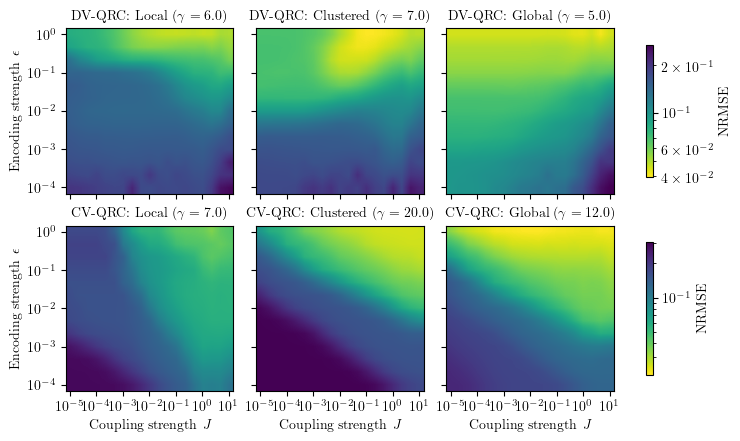

In [5]:
metrics = [
    # (data_column, metric_label)
    ("first_moment_nrmse_test_average_mean", "NRMSE"),
]

threshold = None  # set to a float to filter weak grids

for mean_col, metric_label in metrics:
    
    # --- Pre-processing: Extract the [0] element from the array ---
    for row_label, cols in models_data:
        for idx, (col_label, df) in enumerate(cols):
            
            # 1. Filter for d == 3
            if 'd' in df.columns:
                df = df[df['d'] == 3].copy()
                # Overwrite the tuple in the list with the filtered DataFrame
                cols[idx] = (col_label, df) 
                
            # 2. Extract the first element
            if mean_col in df.columns:
                # Safely extract the first element if it's an array/list, otherwise keep as is
                df['extracted_val'] = df[mean_col].apply(lambda x: x[0] if isinstance(x, (np.ndarray, list)) else x)
    # --------------------------------------------------------------
    
    # 1. Determine global coordinate grids across ALL DataFrames to ensure perfectly aligned axes
    all_enc_vals = set()
    all_cs_vals = set()
    
    for row_label, cols in models_data:
        for col_label, df in cols:
            if "encoding_strength" in df.columns:
                all_enc_vals.update(df["encoding_strength"].dropna().unique())
            if "coupling_strength" in df.columns:
                all_cs_vals.update(df["coupling_strength"].dropna().unique())

    # Sort the coordinates to ensure the grid is strictly ordered
    enc_vals = sorted(list(all_enc_vals))
    cs_vals = sorted(list(all_cs_vals))

    if not enc_vals or not cs_vals:
        print(f"\nNo valid coordinates found for metric: {metric_label}. Skipping.")
        continue

    # --- Calculate clean log ticks based on the global grid ---
    x_ticks = [idx for idx, val in enumerate(cs_vals) if np.isclose(np.log10(val), np.round(np.log10(val)), atol=1e-5)]
    x_labels = [f"$10^{{{int(np.round(np.log10(val)))}}}$" for idx, val in enumerate(cs_vals) if np.isclose(np.log10(val), np.round(np.log10(val)), atol=1e-5)]

    y_ticks = [idx for idx, val in enumerate(enc_vals) if np.isclose(np.log10(val), np.round(np.log10(val)), atol=1e-5)]
    y_labels = [f"$10^{{{int(np.round(np.log10(val)))}}}$" for idx, val in enumerate(enc_vals) if np.isclose(np.log10(val), np.round(np.log10(val)), atol=1e-5)]
    # ----------------------------------------------------------

    # 2. Set up the 2x3 Figure
    fig, axes = plt.subplots(
        nrows=2, 
        ncols=3,
        figsize=(7.3, 4.3),  
        sharex=True,
        sharey=True,
        squeeze=False,
        constrained_layout=True 
    )

    print(f"\n--- Processing Metric: {metric_label} ---")

    # 3. Iterate through the models_data structure row by row
    for i, (row_label, cols) in enumerate(models_data):
        
        # Calculate row-specific minimums and maximums for the color scale
        row_vmin = float('inf')
        row_vmax = float('-inf')
        
        for col_label, df in cols:
            if 'extracted_val' in df.columns:
                valid_data = df['extracted_val'].dropna()
                # Filter out zero or negative values since LogNorm requires positive floats
                valid_data = valid_data[valid_data > 0]
                if not valid_data.empty:
                    row_vmin = min(row_vmin, valid_data.min())
                    row_vmax = max(row_vmax, valid_data.max())
                    
        # Fallback if a row is completely empty or has no positive values
        if row_vmin == float('inf') or row_vmin <= 0:
            row_vmin, row_vmax = 1e-5, 1  
            
        row_im = None
        
        # Plot each column for the current row
        for j, (col_label, df) in enumerate(cols):
            ax = axes[i, j]
            
            # Print maximum values for this specific subplot
            if 'extracted_val' in df.columns and not df['extracted_val'].dropna().empty:
                min_idx = df['extracted_val'].idxmin()
                min_row = df.loc[min_idx]
                print(f"Min {metric_label} for {row_label} ({col_label}): {min_row['extracted_val']:.4f}")
            
            # Extract the unique gamma value safely
            gamma_str = ""
            if "gamma" in df.columns:
                unique_gammas = df["gamma"].dropna().unique()
                if len(unique_gammas) > 0:
                    gamma_val = unique_gammas[0]
                    # Format gamma to append to the title
                    gamma_str = r" ($\gamma=" + str(gamma_val) + r"$)"
            
            # Combine original title logic with the extracted gamma
            full_title = f"{row_label}: {col_label}{gamma_str}"
            
            if 'extracted_val' not in df.columns:
                sub = pd.DataFrame() # Empty frame to trigger the "no data" condition
            else:
                sub = df.dropna(subset=['extracted_val'])
            
            if sub.empty or (threshold is not None and sub['extracted_val'].max() <= threshold):
                ax.text(0.5, 0.5, "no data\nor below threshold", ha="center", va="center",
                        transform=ax.transAxes, alpha=0.6)
                ax.set_title(full_title)
                continue

            pivot_df = sub.pivot_table(
                index="encoding_strength", 
                columns="coupling_strength", 
                values='extracted_val',
                aggfunc="mean" 
            )
            
            # Reindex ensures identical shape and axis alignment
            pivot_df = pivot_df.reindex(index=enc_vals, columns=cs_vals)

            # Plot heatmap using LogNorm
            row_im = ax.imshow(
                pivot_df.values, 
                cmap="viridis_r", 
                aspect="auto", 
                origin="lower", 
                norm=LogNorm(vmin=row_vmin, vmax=row_vmax), # <-- Updated for log scale
                interpolation="bilinear" 
            )

            # Apply the filtered log ticks 
            ax.set_xticks(x_ticks)
            ax.set_xticklabels(x_labels)
            ax.set_yticks(y_ticks)
            ax.set_yticklabels(y_labels)

            # Set the updated title
            ax.set_title(full_title, fontsize=10)

            # Only label axes on the outer edges
            if i == len(models_data) - 1:
                ax.set_xlabel(r"Coupling strength $J$")
            if j == 0:
                ax.set_ylabel(r"Encoding strength $\epsilon$")

        # 4. Attach a colorbar to the current row
        if row_im is not None:
            # Updated the label to output 'NRMSE'
            fig.colorbar(row_im, ax=axes[i, :], label="NRMSE", shrink=0.8, aspect=20)

    # Saved file name updated for NRMSE
    plt.savefig(f"../Plots/nrmse_comparison_heatmap.pdf")
    plt.show()